In [1]:
from string import punctuation
from google.colab import drive
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('wordnet')
from nltk import pos_tag
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, accuracy_score
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import string
from sklearn.feature_extraction.text import CountVectorizer
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
import string
import nltk
import re
nltk.download('omw-1.4')
from nltk.util import defaultdict
!pip install pyspellchecker
from spellchecker import SpellChecker
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline as SkPipeline
from nltk.corpus import wordnet

drive.mount('/content/drive')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 29.4 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
df = pd.read_csv('/content/drive/MyDrive/Bath/NLP/cw_data.csv', header=None, names=['text', 'label'])

print(df.shape)
#print(df['text'].head(25))

print(f'Samples: {len(df)}   Classes: {df["label"].nunique()}')
print(df['label'].value_counts())

random = 63

SPELLING_FIXES = {
    r'\bacct\b': 'account',
    r'\baccts\b': 'accounts',
    r'\bpls\b': 'please',
    r'\bapplication\b': 'app',
    r'\bwat\b': 'what',
    r'\bemial\b': 'email',
    r'\b2\b': 'to',
    r'\bw/out\b': 'without',
    r'\bw/\b': 'with',
    r'\bpwd\b': 'password',
    r'\bcant\b': 'cannot',
    r'\bwont\b': 'will not',
    r'\bdidnt\b':  'did not',
    r'\bdoesnt\b': 'does not',
    r'\bisnt\b':   'is not',
    r'\bwasnt\b':  'was not',
    r'\b(?:two|2)[\s-]*factor[\s-]*(?:authentication|auth)\b': '2fa',
    r'\binfo\b': 'information'
}

def lowercase(texts):
  return [t.lower() for t in texts]

def remove_punctuation(texts):
    cleaned_texts = []
    for t in texts:
        t = re.sub(r'[^\w\s]', '', t)
        cleaned_texts.append(t)
    return cleaned_texts

def remove_hidden_characters(texts):
  cleaned_texts = []
  for t in texts:
    cleaned_texts.append(t.replace("\n", " ").replace("\t", " ").replace("\'", ''))
  return cleaned_texts

def whitespace_removal(texts):
  return [t.strip() for t in texts]

def tokenise(texts):
  tokenised_texts = []
  tokenised_texts = [word_tokenize(t) for t in texts]
  return tokenised_texts


def remove_stopwords(texts):
  cleaned_texts = []
  stop_words = list(stopwords.words('english'))
  for text in texts:
    cleaned_texts.append([w for w in text if not w in stop_words])
  return cleaned_texts

def stem_texts(texts):
  stemmer = PorterStemmer()
  return [[stemmer.stem(word) for word in text] for text in texts]

def get_pos(tag):
  if tag.startswith('J'):
      return wordnet.ADJ
  elif tag.startswith('V'):
      return wordnet.VERB
  elif tag.startswith('R'):
      return wordnet.ADV
  else:
      return wordnet.NOUN

def lemmatise_texts(texts):
  lemmatiser = WordNetLemmatizer()
  lemmatised_texts = []
  for text in texts:
      pos_tags = pos_tag(text)
      lemmatised_texts.append([lemmatiser.lemmatize(tok, get_pos(tag)) for tok, tag in pos_tags])
  return lemmatised_texts


def preprocess(texts, reduction='s'):
    texts = lowercase(texts)

    cleaned_texts = []
    for text in texts:
        for pattern, replacement in SPELLING_FIXES.items():
            text = re.sub(pattern, replacement, text)
        cleaned_texts.append(text)
    texts = cleaned_texts

    texts = remove_punctuation(texts)
    texts = remove_hidden_characters(texts)
    texts = whitespace_removal(texts)

    texts = tokenise(texts)

    texts = remove_stopwords(texts)

    if reduction == 's':
        texts = stem_texts(texts)
    else:
        texts = lemmatise_texts(texts)

    return texts


X = df['text'].values #numpy array
y = df['label'].values


X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random, stratify=y)
print(type(X_train_raw))

print(df['text'].iloc[25])
print(preprocess([df['text'].iloc[25]]))

(308, 2)
Samples: 308   Classes: 14
label
payment_issue              33
shipping_delay             29
notification_settings      24
delete_account             23
subscription_management    23
update_email               23
data_privacy               22
order_tracking             22
billing_history            21
account_recovery           21
refund_request             21
reset_password             20
login_issue                16
two_factor_auth            10
Name: count, dtype: int64
<class 'numpy.ndarray'>
how long refund show in acct?
[['long', 'refund', 'show', 'account']]


In [3]:
df['tokenised'] = preprocess(df['text'].tolist(), reduction='l')
display(df[['text', 'tokenised','label']].sample(10, random_state=random))


all_tokens = [token for sublist in df['tokenised'] for token in sublist]
token_freq = Counter(all_tokens)

print(f'Vocabulary size: {len(token_freq)}')
print('\nTop 20 lemmas:')
for lemma, freq in token_freq.most_common(20):
    print(f'  {lemma:20s} {freq}')

,text,tokenised,label
267,download GDPR data copy — steps?,"[download, gdpr, data, copy, step]",data_privacy
254,how 2 delete my acct permanently?,"[delete, account, permanently]",delete_account
128,Password reset: what steps should I follow on ...,"[password, reset, step, follow, new, laptop]",reset_password
295,I forgot my password — how can I recover acces...,"[forgot, password, recover, access, laptop]",reset_password
285,some credit card work some fail — why?,"[credit, card, work, fail]",payment_issue
8,access past bills France?,"[access, past, bill, france]",billing_history
300,cant update emial if acct is locked wat do?,"[update, email, account, lock]",update_email
10,failed payment affect acct status?,"[failed, payment, affect, account, status]",payment_issue
42,where see billing history?,"[see, bill, history]",billing_history
140,how 2 request refund?,"[request, refund]",refund_request


Vocabulary size: 303

Top 20 lemmas:
  account              59
  possible             31
  email                30
  payment              27
  subscription         25
  refund               25
  notification         24
  fail                 23
  password             23
  data                 21
  reset                21
  delete               20
  track                19
  order                18
  update               17
  change               16
  request              15
  step                 15
  help                 13
  please               13


In [4]:
X_train_lemma = preprocess(X_train_raw, reduction='l')
X_test_lemma = preprocess(X_test_raw, reduction='l')

# vectorise using bag of words (countvectorizer)

bow_vectoriser = CountVectorizer(
    ngram_range=(2,2),
    tokenizer=lambda x: x,
    preprocessor=lambda x: x,
    token_pattern=None,
    lowercase=False
)
#min df?


X_train_bow = bow_vectoriser.fit_transform(X_train_lemma)
X_test_bow = bow_vectoriser.transform(X_test_lemma)


clf = LogisticRegression(random_state=random)
clf.fit(X_train_bow, y_train)

y_pred = clf.predict(X_test_bow)


print(f"Accuracy: {accuracy_score(y_test, y_pred)} (macro)")
print(f"Precision: {precision_score(y_test, y_pred, average='macro')} (macro)")
print(f"Recall: {recall_score(y_test, y_pred, average='macro')} (macro)")
print(f"F1 Score: {f1_score(y_test, y_pred, average='macro')} (macro)")


print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.6935483870967742 (macro)
Precision: 0.7928571428571428 (macro)
Recall: 0.6583333333333333 (macro)
F1 Score: 0.6765873015873015 (macro)
                         precision    recall  f1-score   support

       account_recovery       1.00      0.50      0.67         4
        billing_history       1.00      0.25      0.40         4
           data_privacy       0.75      0.75      0.75         4
         delete_account       0.80      0.80      0.80         5
            login_issue       1.00      0.67      0.80         3
  notification_settings       1.00      1.00      1.00         5
         order_tracking       0.75      0.75      0.75         4
          payment_issue       0.33      1.00      0.50         7
         refund_request       0.80      1.00      0.89         4
         reset_password       1.00      1.00      1.00         4
         shipping_delay       1.00      0.50      0.67         6
subscription_management       0.67      0.40      0.50         5
       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


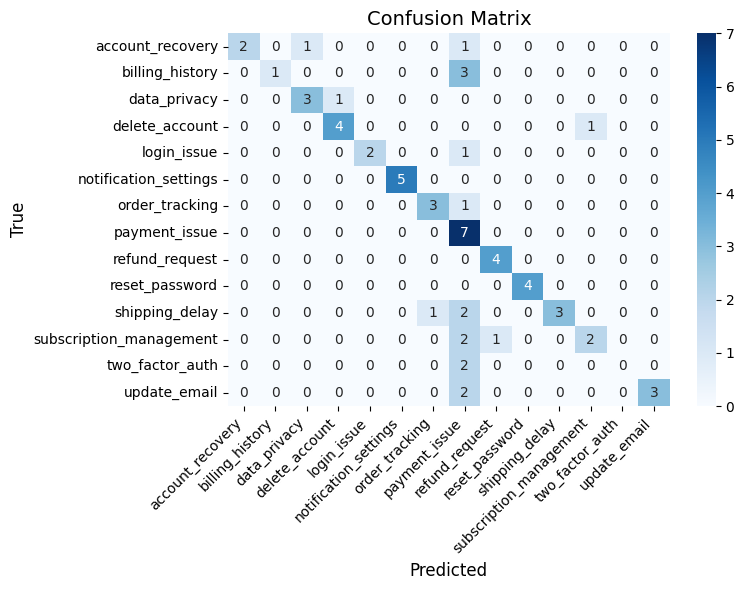

accuracy            : 0.5911  (±0.0953)
f1_macro            : 0.5805  (±0.0893)
precision_macro     : 0.7215  (±0.0485)
recall_macro        : 0.5623  (±0.0926)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [5]:
labels = sorted(df['label'].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

pipe = SkPipeline([
    ('bow', CountVectorizer(
    ngram_range=(2,2),
    tokenizer=lambda x: x,
    preprocessor=lambda x: x,
    token_pattern=None,
    lowercase=False
)),
    ('clf',   LogisticRegression(random_state=random))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random)
cv  = cross_validate(pipe, preprocess(X, reduction='l'), y, cv=skf,
                     scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'])

for m in ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']:
    s = cv[f'test_{m}']
    print(f'{m:20s}: {s.mean():.4f}  (±{s.std():.4f})')

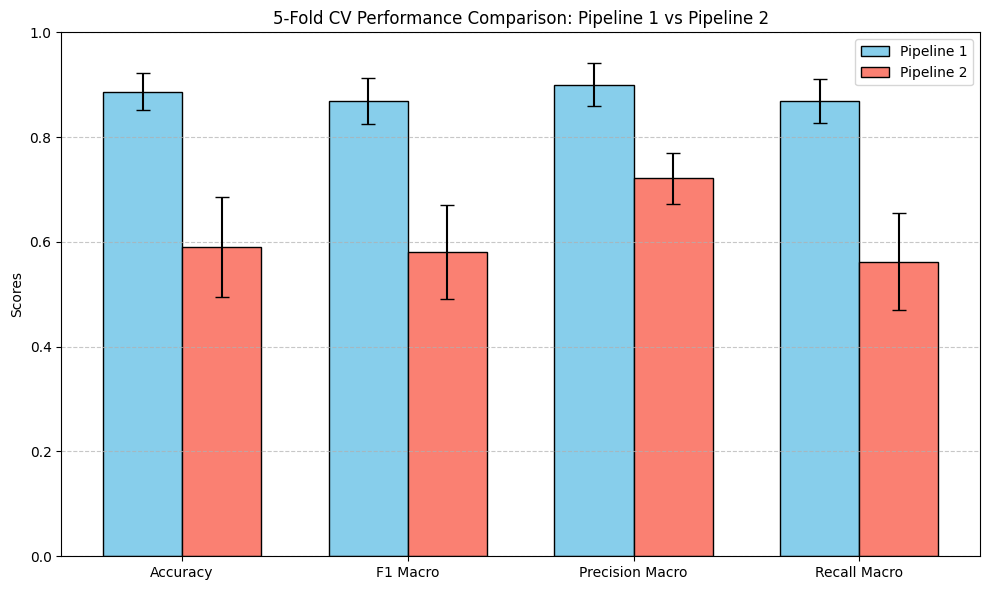

In [9]:
metrics = ['Accuracy', 'F1 Macro', 'Precision Macro', 'Recall Macro']


p1_means = [0.8866, 0.8693, 0.9001, 0.8688]
p1_std = [0.0349, 0.0436, 0.0414, 0.0415]

p2_means = [0.5911, 0.5805, 0.7215, 0.5623]
p2_std = [0.0953, 0.0893, 0.0485, 0.0926]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, p1_means, width, yerr=p1_std,
                label='Pipeline 1', capsize=5, color='skyblue', edgecolor='black')
rects2 = ax.bar(x + width/2, p2_means, width, yerr=p2_std,
                label='Pipeline 2', capsize=5, color='salmon', edgecolor='black')

ax.set_ylabel('Scores')
ax.set_title('5-Fold CV Performance Comparison: Pipeline 1 vs Pipeline 2')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.0)
ax.legend()

fig.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [7]:
mis = pd.DataFrame({
    'raw_text'  : X_test_raw,
    'tokenised' : X_test_lemma,
    'true_label': y_test,
    'pred_label': y_pred
})

mis = mis[mis['true_label'] != mis['pred_label']]

print(f'Total Misclassified: {len(mis)} / {len(y_test)}')
display(mis.head(20))

feature_names = bow_vectoriser.get_feature_names_out()
print('Top 5 predictive features per class:')

for i, cls in enumerate(clf.classes_):
    top = clf.coef_[i].argsort()[-5:][::-1]
    print(f'{cls:30s}: {[feature_names[j] for j in top]}')

Total Misclassified: 19 / 62


,raw_text,tokenised,true_label,pred_label
2,order tracking not working properly?,"[order, track, work, properly]",order_tracking,payment_issue
8,recovery request submitted — how long?,"[recovery, request, submit, long]",account_recovery,data_privacy
9,shipment marked delivered but not received!,"[shipment, mark, deliver, receive]",shipping_delay,order_tracking
14,email change fails… wat to do?,"[email, change, fails]",update_email,payment_issue
19,cancel subscription before acct deletion?,"[cancel, subscription, account, deletion]",delete_account,subscription_management
24,Why do I get a security warning every time I t...,"[get, security, warn, every, time, try, login]",login_issue,payment_issue
27,delete personal data without deleting acct?,"[delete, personal, data, without, delete, acco...",data_privacy,delete_account
29,billing discrepancy invoice total not match re...,"[billing, discrepancy, invoice, total, match, ...",billing_history,payment_issue
33,subscription canceled but still charged help pls,"[subscription, cancel, still, charge, help, pl...",subscription_management,refund_request
34,How do I reset my two-factor authentication de...,"[reset, 2fa, device]",two_factor_auth,payment_issue


Top 5 predictive features per class:
account_recovery              : ['recover account', 'account recovery', 'recovery fail', 'fail next', 'email possible']
billing_history               : ['bill history', 'download invoice', 'access past', 'past bill', 'duplicate charge']
data_privacy                  : ['personal data', 'data request', 'data company', 'data share', '3rd party']
delete_account                : ['delete account', 'account deletion', 'confirmation deletion', 'deletion immediate', 'deletion get']
login_issue                   : ['log account', 'cant log', 'im unable', 'unable sign', 'sign account']
notification_settings         : ['notification setting', 'push notification', 'tone event', 'notification tone', 'event possible']
order_tracking                : ['track order', 'track international', 'track information', 'international order', 'mark deliver']
payment_issue                 : ['credit card', 'bank transfer', 'block account', 'payment block', 'work fail']
refun